In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv")

df = df.sort_values(["Country", "Year"]).reset_index(drop=True)


In [16]:
print("Shape:", df.shape)
display(df.head())

df.info()


Shape: (155, 27)


,Country,Year,D_Expenditure_GDP,Conflict_Intensity,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP),Environmental impact (CO2e/capita),"PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)",Refugees,Asylum Seekers,...,Unemployment_Male_of_TMF,Unemployment_Female_of_TFF,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
0,CHN,1994,1.693480,NaN,NaN,1.98571,2.56,NaN,113908,0,...,3.216,2.522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHN,1995,1.686234,NaN,NaN,1.84192,2.79,NaN,104691,0,...,3.326,2.609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHN,1996,1.652727,NaN,NaN,1.85339,2.74,NaN,105806,0,...,3.459,2.713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CHN,1997,1.632651,NaN,NaN,NaN,2.79,NaN,106731,0,...,3.581,2.808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CHN,1998,1.655081,NaN,NaN,1.84433,2.84,NaN,109396,0,...,3.592,2.817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 27 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   Country                                                                 155 non-null    object 
 1   Year                                                                    155 non-null    int64  
 2   D_Expenditure_GDP                                                       155 non-null    float64
 3   Conflict_Intensity                                                      0 non-null      float64
 4   Health_Expenditure_(% of GDP)                                           116 non-null    float64
 5   Education_Expenditure_(% of GDP)                                        125 non-null    float64
 6   Environmental impact (CO2e/capita)                                      150 non-nu

In [17]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100 ).round(2)

missing_df = pd.DataFrame({
    "Missing": missing,
    "Missing %": missing_pct
})

display(missing_df[missing_df["Missing"] > 0])

,Missing,Missing %
Conflict_Intensity,155,100.00
"PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)",155,100.00
Unnamed: 26,155,100.00
Unnamed: 19,155,100.00
Unnamed: 20,155,100.00
Unnamed: 21,155,100.00
Unnamed: 22,155,100.00
Unnamed: 23,155,100.00
Unnamed: 24,155,100.00
Unnamed: 25,155,100.00


In [18]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Year,155.0,2.009000e+03,8.973265e+00,1.994000e+03,2.001000e+03,2.009000e+03,2.017000e+03,2.024000e+03
D_Expenditure_GDP,155.0,2.778980e+00,1.026659e+00,1.605260e+00,1.924853e+00,2.422716e+00,3.505406e+00,7.052339e+00
Conflict_Intensity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Health_Expenditure_(% of GDP),116.0,9.234967e+00,4.139571e+00,3.674914e+00,5.166851e+00,9.722002e+00,1.149920e+01,1.881325e+01
Education_Expenditure_(% of GDP),125.0,4.753348e+00,1.123607e+00,1.841920e+00,3.988450e+00,4.929770e+00,5.554520e+00,6.738697e+00
Environmental impact (CO2e/capita),150.0,9.885333e+00,4.977291e+00,2.560000e+00,5.962500e+00,8.955000e+00,1.255750e+01,2.101000e+01
"PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)",0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Refugees,155.0,5.231060e+04,7.201012e+04,1.400000e+01,9.800000e+01,4.260000e+02,1.074135e+05,2.513940e+05
Asylum Seekers,155.0,1.449966e+04,3.131107e+04,0.000000e+00,4.300000e+01,2.660000e+02,1.544400e+04,1.809600e+05
Total number of deaths,155.0,3.982581e+01,2.508682e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.753000e+03


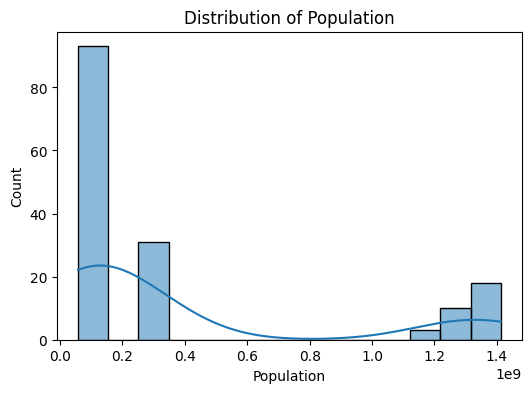

In [22]:
targets = ["Population"]

for col in targets:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde=True)
  plt.title(f"Distribution of {col}")
  plt.show()

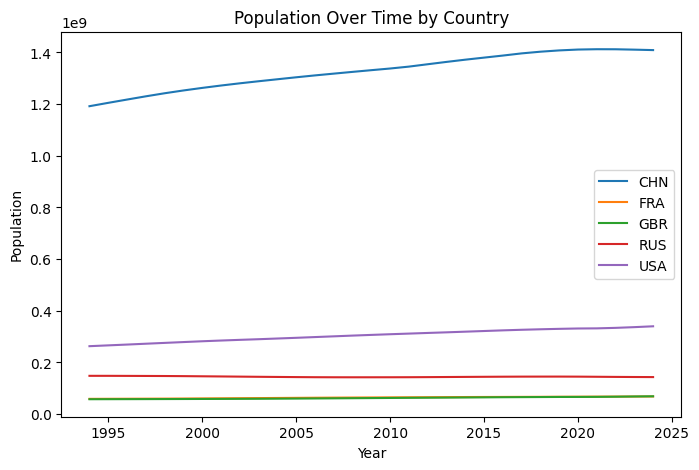

In [23]:
for col in targets:
    plt.figure(figsize=(8,5))
    for country in df["Country"].unique():
        subset = df[df["Country"] == country]
        plt.plot(subset["Year"], subset[col], label=country)
    plt.title(f"{col} Over Time by Country")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.legend()
    plt.show()


In [20]:
empty_cols = [col for col in df.columns if df[col].isnull().sum() == df.shape[0]]
df = df.drop(columns=empty_cols)

In [21]:
df

,Country,Year,D_Expenditure_GDP,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP),Environmental impact (CO2e/capita),Refugees,Asylum Seekers,Total number of deaths,Population,GDP_Growth_Annual,GDP_PerCapita_Growth_Annual,GDP_Current_USDollars,Inflation_Annual,Unemployment_Total_of_TLF,Unemployment_Male_of_TMF,Unemployment_Female_of_TFF
0,CHN,1994,1.693480,NaN,1.985710,2.56,113908,0,0,1191835000,13.072710,11.801890,5.670000e+11,24.256990,2.900,3.216,2.522
1,CHN,1995,1.686234,NaN,1.841920,2.79,104691,0,0,1204855000,11.032810,9.832961,7.380000e+11,16.791230,3.000,3.326,2.609
2,CHN,1996,1.652727,NaN,1.853390,2.74,105806,0,0,1217550000,9.976200,8.829514,8.690000e+11,8.313160,3.120,3.459,2.713
3,CHN,1997,1.632651,NaN,NaN,2.79,106731,0,4,1230075000,9.287647,8.174846,9.680000e+11,2.786465,3.230,3.581,2.808
4,CHN,1998,1.655081,NaN,1.844330,2.84,109396,0,0,1241935000,7.920792,6.890190,1.040000e+12,-0.773190,3.240,3.592,2.817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,USA,2020,3.650514,18.813253,5.395320,13.46,349,2491,0,331577720,-2.163030,-2.561810,2.140000e+13,1.233584,8.055,7.807,8.356
151,USA,2021,3.417094,17.506386,5.420380,14.31,426,1662,0,332099760,6.055053,5.888341,2.370000e+13,4.697859,5.349,5.463,5.210
152,USA,2022,3.343259,16.496140,5.382429,14.33,1327,2115,0,334017321,2.512375,1.923862,2.600000e+13,8.002800,3.650,3.680,3.613
153,USA,2023,3.361836,NaN,NaN,13.90,1229,2051,0,336806231,2.887556,2.035600,2.770000e+13,4.116338,3.638,3.795,3.450


In [24]:
target = 'Population'
feature_cols = [
    'Country', 'Year',
    'D_Expenditure_GDP',
    'Health_Expenditure_(% of GDP)',
    'Education_Expenditure_(% of GDP)',
    'Environmental impact (CO2e/capita)',
    'GDP_Growth_Annual',
    'GDP_PerCapita_Growth_Annual',
    'GDP_Current_USDollars',
    'Inflation_Annual',
    'Unemployment_Total_of_TLF',
    'Unemployment_Male_of_TMF',
    'Unemployment_Female_of_TFF'
]

X = df[feature_cols]
y = df[target]

In [28]:
categorical_features = ['Country']
numeric_features = [col for col in feature_cols if col not in categorical_features]

# =========================
# PREPROCESSING PIPELINE
# =========================

# Numeric pipeline: impute missing values with mean, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: one-hot encode
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


In [29]:
X_processed = preprocessor.fit_transform(X)

print("Original X shape:", X.shape)
print("Processed X shape:", X_processed.shape)

Original X shape: (155, 13)
Processed X shape: (155, 17)


# **Random** **Forest**

/tmp/ipython-input-1992761311.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  country_perf = comparison_df.groupby('Country').apply(


=== Country-wise Performance ===
  Country           MAE          RMSE        R2
0     CHN  4.007116e+06  4.476534e+06  0.989441
1     FRA  2.702268e+05  3.374093e+05  0.988860
2     GBR  5.835530e+05  6.577923e+05  0.953553
3     RUS  4.735939e+05  5.271668e+05  0.864473
4     USA  1.552095e+06  1.844260e+06  0.992672

--- CHN ---
    Year  Actual_Population  Predicted_Population
9   2003         1288400000          1.281930e+09
12  2006         1311020000          1.303892e+09
15  2009         1331260000          1.325868e+09
18  2012         1354190000          1.350969e+09
19  2013         1363240000          1.365820e+09
24  2018         1402760000          1.398769e+09
29  2023         1410710000          1.409432e+09
30  2024         1408975000          1.406977e+09

--- FRA ---
    Year  Actual_Population  Predicted_Population
31  1994           59324863          5.951201e+07
42  2005           63180854          6.260992e+07
45  2008           64375116          6.406831e+07
60 

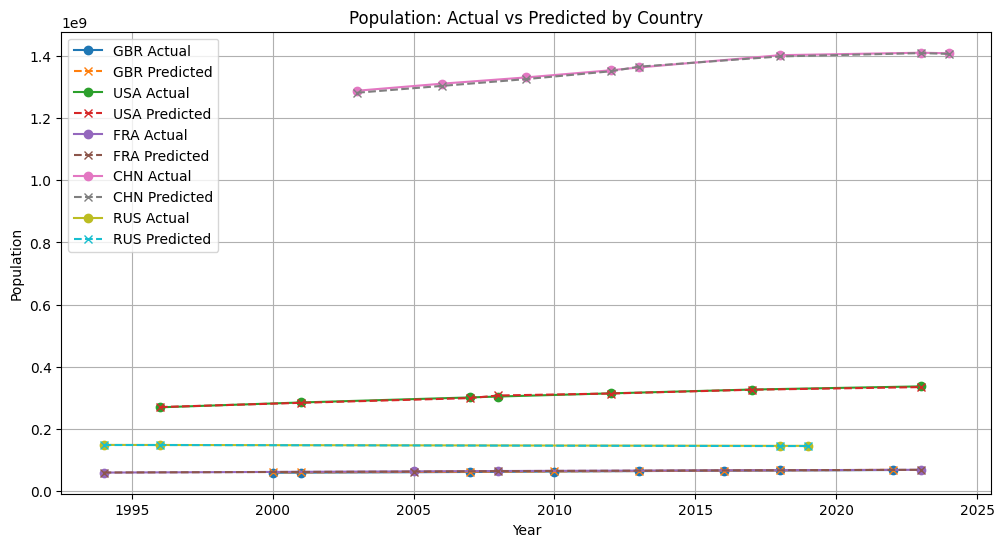

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================
# Features and target
# =====================
feature_cols = ['Country', 'Year', 'D_Expenditure_GDP']
target = 'Population'

X = df[feature_cols]
y = df[target]

categorical_features = ['Country']
numeric_features = ['Year', 'D_Expenditure_GDP']

# =====================
# Preprocessing pipeline
# =====================
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_processed = preprocessor.fit_transform(X)

# =====================
# Train/test split (track original indices)
# =====================
indices = np.arange(len(y))  # keep track of original row indices
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_processed, y, indices, test_size=0.2, random_state=42
)

# Original X_test for comparison
X_test_orig = X.iloc[idx_test].copy()

# =====================
# Train Random Forest
# =====================
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# =====================
# Predict on test set
# =====================
y_pred = rf_model.predict(X_test)

# =====================
# Combine Actual and Predicted
# =====================
comparison_df = X_test_orig.copy()
comparison_df['Actual_Population'] = y_test.values
comparison_df['Predicted_Population'] = y_pred

# =====================
# Country-wise performance metrics
# =====================
country_perf = comparison_df.groupby('Country').apply(
    lambda df: pd.Series({
        'MAE': mean_absolute_error(df['Actual_Population'], df['Predicted_Population']),
        'RMSE': np.sqrt(mean_squared_error(df['Actual_Population'], df['Predicted_Population'])),
        'R2': r2_score(df['Actual_Population'], df['Predicted_Population'])
    })
).reset_index()

print("=== Country-wise Performance ===")
print(country_perf)

# =====================
# Country-wise Actual vs Predicted table
# =====================
for country, group in comparison_df.groupby('Country'):
    print(f"\n--- {country} ---")
    print(group[['Year', 'Actual_Population', 'Predicted_Population']].sort_values('Year'))

# =====================
# Country-wise line plot: Actual vs Predicted
# =====================
plt.figure(figsize=(12, 6))
countries = comparison_df['Country'].unique()

for country in countries:
    group = comparison_df[comparison_df['Country'] == country].sort_values('Year')
    plt.plot(group['Year'], group['Actual_Population'], marker='o', label=f'{country} Actual')
    plt.plot(group['Year'], group['Predicted_Population'], marker='x', linestyle='--', label=f'{country} Predicted')

plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population: Actual vs Predicted by Country')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-1037976446.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  country_perf = comparison_df.groupby('Country').apply(


=== Country-wise Performance (2020-2024) ===
  Country           MAE          RMSE         R2
0     CHN  1.036176e+07  1.096742e+07 -80.224108
1     FRA  1.732299e+06  1.890482e+06 -33.492917
2     GBR  2.633712e+06  2.886795e+06  -8.620305
3     RUS  8.034034e+05  1.028945e+06  -1.776136
4     USA  6.818935e+06  7.353850e+06  -4.360353

--- CHN ---
    Year  Actual_Population  Predicted_Population
26  2020         1411100000          1.393733e+09
27  2021         1412360000          1.403505e+09
28  2022         1412175000          1.403505e+09
29  2023         1410710000          1.403505e+09
30  2024         1408975000          1.399263e+09

--- FRA ---
    Year  Actual_Population  Predicted_Population
57  2020           67601110          6.655726e+07
58  2021           67842811          6.684894e+07
59  2022           68065015          6.672930e+07
60  2023           68287487          6.575806e+07
61  2024           68516699          6.575806e+07

--- GBR ---
    Year  Actual_Popul

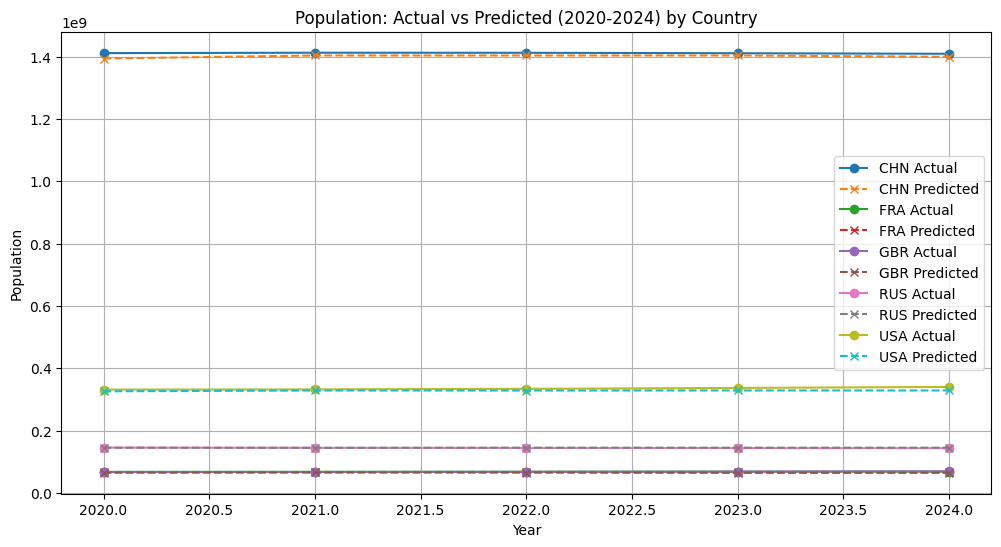

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================
# Features and target
# =====================
feature_cols = ['Country', 'Year', 'D_Expenditure_GDP']
target = 'Population'

X = df[feature_cols]
y = df[target]

categorical_features = ['Country']
numeric_features = ['Year', 'D_Expenditure_GDP']

# =====================
# Preprocessing pipeline
# =====================
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_processed = preprocessor.fit_transform(X)

# =====================
# Chronological split: Train < 2020, Test 2020-2024
# =====================
test_years = [2020, 2021, 2022, 2023, 2024]

is_test = X['Year'].isin(test_years)
is_train = ~is_test

X_train = X_processed[is_train.values]
y_train = y[is_train]

X_test = X_processed[is_test.values]
y_test = y[is_test]

X_test_orig = X[is_test].copy()

# =====================
# Train Random Forest
# =====================
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# =====================
# Predict on test set
# =====================
y_pred = rf_model.predict(X_test)

# =====================
# Combine Actual and Predicted
# =====================
comparison_df = X_test_orig.copy()
comparison_df['Actual_Population'] = y_test.values
comparison_df['Predicted_Population'] = y_pred

# =====================
# Country-wise performance metrics
# =====================
country_perf = comparison_df.groupby('Country').apply(
    lambda df: pd.Series({
        'MAE': mean_absolute_error(df['Actual_Population'], df['Predicted_Population']),
        'RMSE': np.sqrt(mean_squared_error(df['Actual_Population'], df['Predicted_Population'])),
        'R2': r2_score(df['Actual_Population'], df['Predicted_Population'])
    })
).reset_index()

print("=== Country-wise Performance (2020-2024) ===")
print(country_perf)

# =====================
# Country-wise Actual vs Predicted table
# =====================
for country, group in comparison_df.groupby('Country'):
    print(f"\n--- {country} ---")
    print(group[['Year', 'Actual_Population', 'Predicted_Population']].sort_values('Year'))

# =====================
# Country-wise line plot: Actual vs Predicted
# =====================
plt.figure(figsize=(12, 6))
countries = comparison_df['Country'].unique()

for country in countries:
    group = comparison_df[comparison_df['Country'] == country].sort_values('Year')
    plt.plot(group['Year'], group['Actual_Population'], marker='o', label=f'{country} Actual')
    plt.plot(group['Year'], group['Predicted_Population'], marker='x', linestyle='--', label=f'{country} Predicted')

plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population: Actual vs Predicted (2020-2024) by Country')
plt.legend()
plt.grid(True)
plt.show()


# **ARIMA**

In [38]:
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/u

=== Country-wise Performance (ARIMA, 2020-2024) ===
  Country           MAE          RMSE         R2
0     CHN  9.292458e+06  1.120281e+07 -83.748134
1     FRA  2.863004e+05  3.161139e+05   0.035567
2     GBR  3.982000e+05  4.880748e+05   0.725002
3     RUS  1.301081e+06  1.475176e+06  -4.706157
4     USA  1.053658e+06  1.284219e+06   0.836529


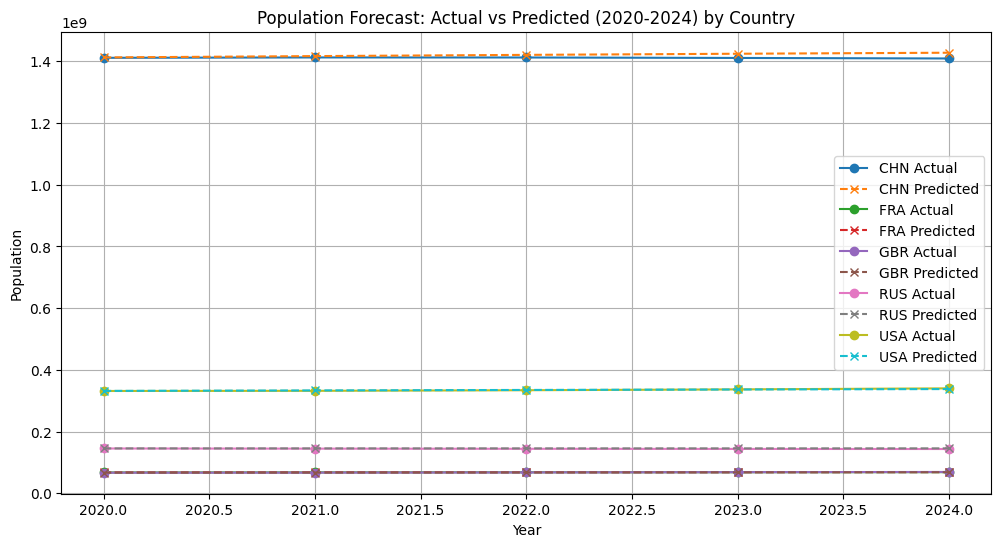

In [40]:
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

test_years = [2020, 2021, 2022, 2023, 2024]
countries = df['Country'].unique()
all_forecasts = []

for country in countries:
    country_data = df[df['Country'] == country].sort_values('Year')
    train_data = country_data[country_data['Year'] < 2020].copy()

    # Ensure train index
    train_data.set_index('Year', inplace=True)

    # Fit auto_arima
    model = auto_arima(
        train_data['Population'],
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore'
    )

    # Forecast length = 5 (2020–2024)
    forecast = model.predict(n_periods=len(test_years))

    # Prepare test dataframe
    test_df = pd.DataFrame({
        'Year': test_years,
        'Actual_Population': country_data[country_data['Year'].isin(test_years)]['Population'].values,
        'Predicted_Population': forecast
    })
    test_df['Country'] = country
    all_forecasts.append(test_df)

# Combine all countries
forecast_df = pd.concat(all_forecasts, ignore_index=True)

# Drop any NaNs before metrics
forecast_df_clean = forecast_df.dropna(subset=['Actual_Population', 'Predicted_Population'])

# Country-wise performance
country_perf = forecast_df_clean.groupby('Country').apply(
    lambda df: pd.Series({
        'MAE': mean_absolute_error(df['Actual_Population'], df['Predicted_Population']),
        'RMSE': np.sqrt(mean_squared_error(df['Actual_Population'], df['Predicted_Population'])),
        'R2': r2_score(df['Actual_Population'], df['Predicted_Population'])
    })
).reset_index()

print("=== Country-wise Performance (ARIMA, 2020-2024) ===")
print(country_perf)

# Plot
plt.figure(figsize=(12,6))
for country in countries:
    group = forecast_df_clean[forecast_df_clean['Country'] == country].sort_values('Year')
    plt.plot(group['Year'], group['Actual_Population'], marker='o', label=f'{country} Actual')
    plt.plot(group['Year'], group['Predicted_Population'], marker='x', linestyle='--', label=f'{country} Predicted')

plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population Forecast: Actual vs Predicted (2020-2024) by Country')
plt.legend()
plt.grid(True)
plt.show()


In [41]:
# ==========================
# IMPORT LIBRARIES
# ==========================
import pandas as pd
import numpy as np

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv')

# Ensure correct sorting
df = df.sort_values(['Country', 'Year'])

# ==========================
# PARAMETERS
# ==========================
FORECAST_YEARS = [2020, 2021, 2022, 2023, 2024]
countries = df['Country'].unique()

all_forecasts = []

# ==========================
# ARIMA MODEL (PER COUNTRY)
# ==========================
for country in countries:

    country_df = df[df['Country'] == country].copy()
    country_df = country_df.sort_values('Year')

    # Train data (before 2020)
    train_df = country_df[country_df['Year'] < 2020].copy()

    # Skip countries with insufficient data
    if len(train_df) < 10:
        continue

    # Set Year as proper numeric index
    train_df.set_index('Year', inplace=True)
    train_df.index = pd.Index(train_df.index, dtype='int')

    y_train = train_df['Population']

    # ==========================
    # AUTO ARIMA (SAFE SETTINGS)
    # ==========================
    model = auto_arima(
        y_train,
        seasonal=False,
        d=1,                    # FIXED differencing for population
        start_p=0,
        start_q=0,
        max_p=3,
        max_q=3,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        trace=False
    )

    # ==========================
    # FORECAST
    # ==========================
    forecast = model.predict(n_periods=len(FORECAST_YEARS))

    # Safety: population cannot be negative
    forecast = np.maximum(forecast, 0)

    # ==========================
    # ACTUAL VALUES
    # ==========================
    test_df = country_df[country_df['Year'].isin(FORECAST_YEARS)].copy()

    # Align lengths safely
    min_len = min(len(test_df), len(forecast))

    result_df = pd.DataFrame({
        'Country': country,
        'Year': FORECAST_YEARS[:min_len],
        'Actual_Population': test_df['Population'].values[:min_len],
        'Predicted_Population': forecast[:min_len]
    })

    all_forecasts.append(result_df)

# ==========================
# COMBINE FORECASTS
# ==========================
forecast_df = pd.concat(all_forecasts, ignore_index=True)

# Drop rows with missing values (important!)
forecast_df_clean = forecast_df.dropna()

# ==========================
# COUNTRY-WISE METRICS
# ==========================
country_perf = (
    forecast_df_clean
    .groupby('Country', as_index=False)
    .apply(lambda x: pd.Series({
        'MAE': mean_absolute_error(x['Actual_Population'], x['Predicted_Population']),
        'RMSE': np.sqrt(mean_squared_error(x['Actual_Population'], x['Predicted_Population'])),
        'R2': r2_score(x['Actual_Population'], x['Predicted_Population'])
    }))
)

print("\n=== Country-wise Performance (ARIMA, 2020–2024) ===")
print(country_perf)

# ==========================
# OVERALL PERFORMANCE
# ==========================
overall_mae = mean_absolute_error(
    forecast_df_clean['Actual_Population'],
    forecast_df_clean['Predicted_Population']
)

overall_rmse = np.sqrt(mean_squared_error(
    forecast_df_clean['Actual_Population'],
    forecast_df_clean['Predicted_Population']
))

overall_r2 = r2_score(
    forecast_df_clean['Actual_Population'],
    forecast_df_clean['Predicted_Population']
)

print("\n=== Overall ARIMA Performance ===")
print(f"MAE  : {overall_mae:,.0f}")
print(f"RMSE : {overall_rmse:,.0f}")
print(f"R²   : {overall_r2:.3f}")



=== Country-wise Performance (ARIMA, 2020–2024) ===
  Country           MAE          RMSE          R2
0     CHN  1.922261e+07  2.239770e+07 -337.752838
1     FRA  2.863004e+05  3.161139e+05    0.035567
2     GBR  3.244080e+05  3.759888e+05    0.836805
3     RUS  7.809717e+05  9.021631e+05   -1.134157
4     USA  1.587218e+06  1.789559e+06    0.682564

=== Overall ARIMA Performance ===
MAE  : 4,440,301
RMSE : 10,058,974
R²   : 1.000
